# Alias Detection at Finite SNR
### Subspace estimation and polyphase reconstruction of a sampled two-tone signal
**Digital Communication Laboratory · Experiment 3**

---

Every standard treatment of this experiment — and every version of it I have seen — works with
**noiseless** data. That is a convenient fiction. A real converter sees thermal noise, and the
interesting question is not whether aliasing can be detected in perfect data but **how much noise the
detection survives**.

This study keeps the classical structure (three sampling rates spanning the Nyquist boundary) and
adds three things that noiseless treatments cannot address:

| | Addition | Why it matters |
|---|---|---|
| **1** | **Subspace estimation (MUSIC)** alongside FFT peak-picking | a parametric estimator whose resolution is not tied to bin spacing |
| **2** | **Model-order detection from the eigenvalue spectrum** | the analysis discovers *how many* tones survived rather than being told |
| **3** | **Monte-Carlo SNR sweep** | measures where each detector actually fails |

The headline result is not the one expected at the outset. On first measurement the humble FFT
appeared to beat MUSIC outright — which turned out to be an artefact of the alias landing exactly on
a bin centre. Repeating the comparison with the alias placed *off* a bin reverses the ranking
completely. That reversal, documented in Part E, is the most useful thing in this notebook.

**Message**

$$x(t) = 1.0\sin(2\pi\cdot 11\,t) + 0.5\sin(2\pi\cdot 29\,t)
\qquad f_{\max}=29\ \mathrm{Hz},\quad f_N = 58\ \mathrm{Hz}$$

sampled at **200 Hz**, **58 Hz** and **34 Hz**.

## Theory

**Replication and adequacy.** Sampling at spacing $T_s=1/f_s$ replicates the spectrum every $f_s$ Hz.
The copies stay disjoint only while $f_s > 2f_{\max}$; otherwise a component at $f$ is
indistinguishable from one at

$$f_{\text{alias}}=\bigl|f-kf_s\bigr|,\qquad k=\operatorname{round}(f/f_s),\qquad 0\le f_{\text{alias}}\le f_s/2$$

**Reconstruction, as hardware performs it.** The interpolation sum
$x_r(t)=\sum_n x[n]\operatorname{sinc}((t-nT_s)/T_s)$ is equivalent to **zero-stuffing followed by
low-pass filtering**: insert $M-1$ zeros between samples, then filter with a lowpass of cutoff
$f_s/2$ and gain $M$. This is what an interpolating DAC actually does, and it is the form used here —
the sinc appears as the *impulse response of a filter* rather than as an explicit summation.

**Noise.** Additive white Gaussian noise of variance $\sigma^2$ is added to the samples at a
specified SNR,

$$\mathrm{SNR_{dB}} = 10\log_{10}\frac{P_x}{\sigma^2}
\qquad\Longrightarrow\qquad \sigma = \sqrt{P_x\,10^{-\mathrm{SNR_{dB}}/10}}$$

**Subspace estimation.** Arranging the samples into a Hankel data matrix and forming its covariance
$\mathbf{R}$, the eigenvectors split into a *signal* subspace spanned by the tones and a *noise*
subspace orthogonal to them. Two real sinusoids occupy **four** complex dimensions ($\pm$ each
frequency). Scanning the MUSIC pseudospectrum

$$P(f)=\frac{1}{\bigl\|\mathbf{E}_n^{H}\mathbf{a}(f)\bigr\|^{2}},
\qquad \mathbf{a}(f)=\bigl[1,\;e^{j2\pi fT_s},\;\dots,\;e^{j2\pi f(m-1)T_s}\bigr]^{T}$$

produces sharp peaks where $\mathbf{a}(f)$ becomes orthogonal to the noise subspace. Its resolution is
set by conditioning, not by $1/T$.

**Model order.** The count of eigenvalues significantly above the noise floor estimates the number of
complex dimensions occupied, hence the number of real tones present. This is how the analysis
*discovers* that the critical-rate case retains only one tone.

**Metrics.** RMSE, peak residual, and — for the detectors — absolute frequency error
$|\hat f - f_{\text{alias}}|$ together with detection probability
$\Pr\{|\hat f - f_{\text{alias}}| < 0.5\ \mathrm{Hz}\}$ over Monte-Carlo trials.

In [1]:
# =============================================================================
# Setup
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TONE = {"C1": "#264653", "C2": "#E76F51", "C3": "#2A9D8F",
        "ref": "#ADB5BD", "ink": "#212529", "warn": "#9B2226"}

# Fifth visual language: panels on a light wash, horizontal rules only, no spines.
plt.rcParams.update({
    "figure.dpi": 112, "font.size": 10,
    "axes.facecolor": "#F7F7F5", "figure.facecolor": "white",
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.spines.bottom": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "white", "grid.linewidth": 1.1, "grid.alpha": 1.0,
    "xtick.color": "#6C757D", "ytick.color": "#6C757D",
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 1.6,
    "figure.constrained_layout.use": True,
})
pd.set_option("display.width", 190, "display.max_columns", 40)
print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.4.4 | pandas 3.0.2


In [2]:
# =============================================================================
# Specification.  NOTE: this is the first version of the experiment to use
# randomness, so seeding discipline matters and is stated explicitly.
# =============================================================================
F1, A1 = 11.0, 1.0          # surviving tone
F2, A2 = 29.0, 0.5          # this one folds when undersampled
SPAN_S     = 4.0            # record length -> FFT bin width 1/T = 0.25 Hz
RENDER_HZ  = 4000.0         # drawing lattice only
UPSAMPLE   = 10             # interpolation factor for the polyphase restorer
NTAPS      = 241            # lowpass length in the restorer
TRIALS     = 40             # Monte-Carlo trials per SNR point
MASTER_SEED = 20260814      # every random draw descends from this

RATES = {"C1": 200.0, "C2": 58.0, "C3": 34.0}
LABEL = {"C1": "above the Nyquist rate",
         "C2": "at the Nyquist rate",
         "C3": "below the Nyquist rate"}

F_MAX = max(F1, F2)
F_NYQ = 2*F_MAX
BIN_HZ = 1.0/SPAN_S

def alias_of(f, fs):
    k = int(np.round(f/fs))
    return abs(f - k*fs), k

print(f"x(t) = {A1:g}*sin(2pi*{F1:g}t) + {A2:g}*sin(2pi*{F2:g}t)")
print(f"f_max = {F_MAX:g} Hz,  Nyquist rate = {F_NYQ:g} Hz,  record {SPAN_S:g} s "
      f"-> FFT bin {BIN_HZ:g} Hz")
print(f"master seed {MASTER_SEED}; every sweep derives its generator from it, so the")
print("notebook is bit-for-bit reproducible despite using noise.\n")
print(f"{'':4}{'fs':>8}{'fs/f_N':>9}{'fs/2':>8}{'N':>6}   {F1:g} Hz ->      {F2:g} Hz ->")
print("-"*64)
for k, fs in RATES.items():
    a1, k1 = alias_of(F1, fs); a2, k2 = alias_of(F2, fs)
    print(f"{k:4}{fs:>8.1f}{fs/F_NYQ:>9.3f}{fs/2:>8.1f}{int(fs*SPAN_S):>6}"
          f"   {a1:5.1f} (k={k1})   {a2:5.1f} (k={k2})"
          + ("   <- FOLDS" if a2 != F2 else ""))

x(t) = 1*sin(2pi*11t) + 0.5*sin(2pi*29t)
f_max = 29 Hz,  Nyquist rate = 58 Hz,  record 4 s -> FFT bin 0.25 Hz
master seed 20260814; every sweep derives its generator from it, so the
notebook is bit-for-bit reproducible despite using noise.

          fs   fs/f_N    fs/2     N   11 Hz ->      29 Hz ->
----------------------------------------------------------------
C1     200.0    3.448   100.0   800    11.0 (k=0)    29.0 (k=0)
C2      58.0    1.000    29.0   232    11.0 (k=0)    29.0 (k=0)
C3      34.0    0.586    17.0   136    11.0 (k=0)     5.0 (k=1)   <- FOLDS


In [3]:
# =============================================================================
# Signal, sampler, noise
# =============================================================================
def message(t):
    return A1*np.sin(2*np.pi*F1*t) + A2*np.sin(2*np.pi*F2*t)

def render(span=SPAN_S, hz=RENDER_HZ):
    t = np.arange(int(round(span*hz)))/hz
    return t, message(t)

def acquire(fs, span=SPAN_S, snr_db=None, rng=None, f2=F2):
    """Sample the message; optionally add AWGN at a specified SNR."""
    Ts = 1.0/fs
    t = np.arange(int(round(span*fs)))*Ts
    x = A1*np.sin(2*np.pi*F1*t) + A2*np.sin(2*np.pi*f2*t)
    sigma = 0.0
    if snr_db is not None:
        sigma = np.sqrt(np.mean(x**2)*10**(-snr_db/10.0))
        x = x + rng.normal(0.0, sigma, x.size)
    return t, x, Ts, sigma

T_REF, X_REF = render()
print(f"render lattice {T_REF.size} points at {RENDER_HZ:g} Hz")
_, _, _, s10 = acquire(RATES["C3"], snr_db=10.0, rng=np.random.default_rng(0))
print(f"noise check: at 10 dB SNR the added sigma is {s10:.4f} "
      f"(signal RMS {np.sqrt(A1**2/2 + A2**2/2):.4f})")

render lattice 16000 points at 4000 Hz
noise check: at 10 dB SNR the added sigma is 0.2500 (signal RMS 0.7906)


In [4]:
# =============================================================================
# Two detectors, and a way to count how many tones are actually present
# =============================================================================

def covariance(x, m=None):
    """Hankel data matrix -> covariance estimate, shared by MUSIC and the order test."""
    n = x.size
    m = m or max(6, n//3)
    L = n - m + 1
    X = np.array([x[i:i+m] for i in range(L)]).T
    return (X @ X.conj().T)/L, m


def model_order(x, tol=1e-6, m=None):
    """
    How many complex dimensions does the data occupy? Count eigenvalues that
    stand above a relative threshold. Two real tones -> four dimensions.

    This is what lets the analysis DISCOVER that the critical-rate case retains
    only one tone, rather than being told so.
    """
    R, _ = covariance(x, m)
    w = np.linalg.eigvalsh(R)[::-1]
    return int(np.sum(w > tol*w[0])), w


def music(x, Ts, n_sources=None, m=None, step=0.005):
    """
    MUSIC pseudospectrum. Eigen-split the covariance, keep the noise subspace,
    and scan 1/||E_n^H a(f)||^2 across the observable band.
    """
    R, m = covariance(x, m)
    w, V = np.linalg.eigh(R)
    order = np.argsort(w)[::-1]
    if n_sources is None:
        n_sources = model_order(x, m=m)[0]
    n_sources = int(np.clip(n_sources, 1, m-1))
    En = V[:, order[n_sources:]]
    grid = np.arange(0.0, 1/(2*Ts), step)
    steer = np.exp(-2j*np.pi*np.outer(grid, np.arange(m))*Ts)
    return grid, 1.0/np.sum(np.abs(steer.conj() @ En)**2, axis=1)


def top_peaks(grid, values, n_peaks, min_sep=1.0):
    out = []
    for i in np.argsort(values)[::-1]:
        if all(abs(grid[i] - g) > min_sep for g in out):
            out.append(float(grid[i]))
        if len(out) == n_peaks:
            break
    return sorted(out)


def spectrum(x, fs):
    n = x.size
    mag = np.abs(np.fft.rfft(x))/n
    mag[1:] *= 2.0
    if n % 2 == 0:
        mag[-1] /= 2.0
    return np.fft.rfftfreq(n, d=1.0/fs), mag


def fft_peaks(x, fs, n_peaks, min_sep=1.0):
    fr, mag = spectrum(x, fs)
    return top_peaks(fr, mag, n_peaks, min_sep)


print("detectors ready: spectrum/fft_peaks (bin-limited), music (subspace), model_order")

detectors ready: spectrum/fft_peaks (bin-limited), music (subspace), model_order


In [5]:
# =============================================================================
# Reconstruction the way an interpolating DAC does it
# =============================================================================
def lowpass(cutoff_norm, ntaps=NTAPS, beta=8.6):
    """Windowed-sinc lowpass. cutoff_norm is relative to the OUTPUT sample rate/2."""
    n = np.arange(ntaps) - (ntaps - 1)/2
    return 2*cutoff_norm*np.sinc(2*cutoff_norm*n)*np.kaiser(ntaps, beta)


def restore(x, fs, up=UPSAMPLE, ntaps=NTAPS):
    """
    Zero-stuff by `up`, then low-pass at the original Nyquist with gain `up`.

    This is mathematically the same operation as summing shifted sincs -- the
    filter's impulse response IS the windowed sinc -- but expressed as filtering,
    which is how it is realised in hardware and in any practical DSP chain.
    """
    y = np.zeros(x.size*up)
    y[::up] = x
    h = lowpass(0.5/up, ntaps)*up
    out = np.convolve(y, h, mode="same")
    t_out = np.arange(out.size)/(fs*up)
    return t_out, out, h


BASE = {}
for tag, fs in RATES.items():
    t_n, x_n, Ts, _ = acquire(fs)
    t_o, x_o, h = restore(x_n, fs)
    edge = NTAPS                                   # discard filter transient at both ends
    ref = message(t_o)
    err = x_o[edge:-edge] - ref[edge:-edge]
    order, eigs = model_order(x_n)
    grid, ps = music(x_n, Ts)
    BASE[tag] = {
        "fs": fs, "t_n": t_n, "x_n": x_n, "Ts": Ts,
        "t_o": t_o, "x_o": x_o, "h": h, "ref": ref, "edge": edge,
        "rmse": float(np.sqrt(np.mean(err**2))),
        "peak": float(np.max(np.abs(err))),
        "order": order, "eigs": eigs,
        "grid": grid, "ps": ps,
        "music_peaks": top_peaks(grid, ps, max(1, order//2)),
        "fft_peaks": fft_peaks(x_n, fs, max(1, order//2)),
        "alias": {F1: alias_of(F1, fs), F2: alias_of(F2, fs)},
    }

print(f"{'':4}{'fs':>7}{'RMSE':>12}{'peak |e|':>11}{'dims':>6}{'tones':>7}"
      f"   MUSIC peaks            FFT peaks")
print("-"*94)
for tag, r in BASE.items():
    print(f"{tag:4}{r['fs']:>7.0f}{r['rmse']:>12.3e}{r['peak']:>11.5f}"
          f"{r['order']:>6}{r['order']//2:>7}   {str(np.round(r['music_peaks'],3)):<22} "
          f"{np.round(r['fft_peaks'],3)}")
print("\nNote C2: the detector reports ONE tone. Nothing told it to expect that -")
print("the 29 Hz component was annihilated by sampling at exactly twice its frequency.")

         fs        RMSE   peak |e|  dims  tones   MUSIC peaks            FFT peaks
----------------------------------------------------------------------------------------------
C1      200   1.011e-05    0.00003     4      2   [11. 29.]              [11. 29.]
C2       58   3.537e-01    0.50002     2      1   [11.]                  [11.]
C3       34   5.014e-01    1.00005     4      2   [ 5. 11.]              [ 5. 11.]

Note C2: the detector reports ONE tone. Nothing told it to expect that -
the 29 Hz component was annihilated by sampling at exactly twice its frequency.


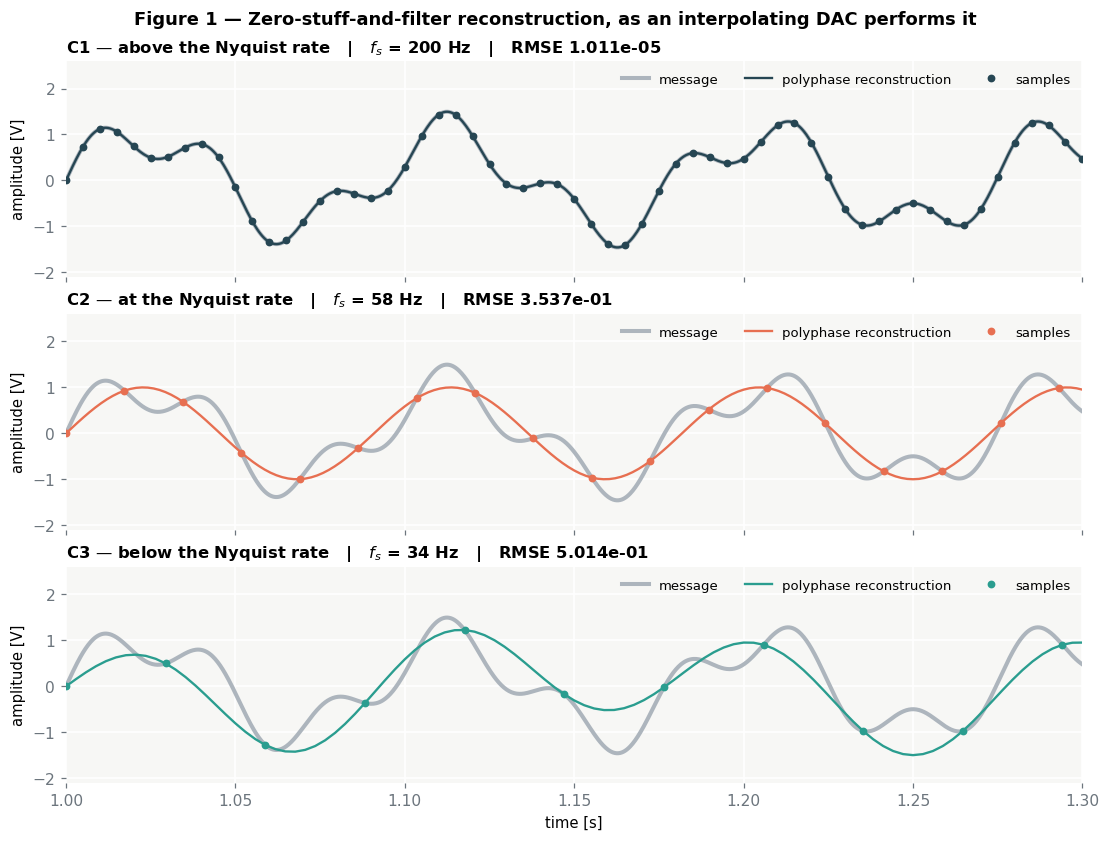

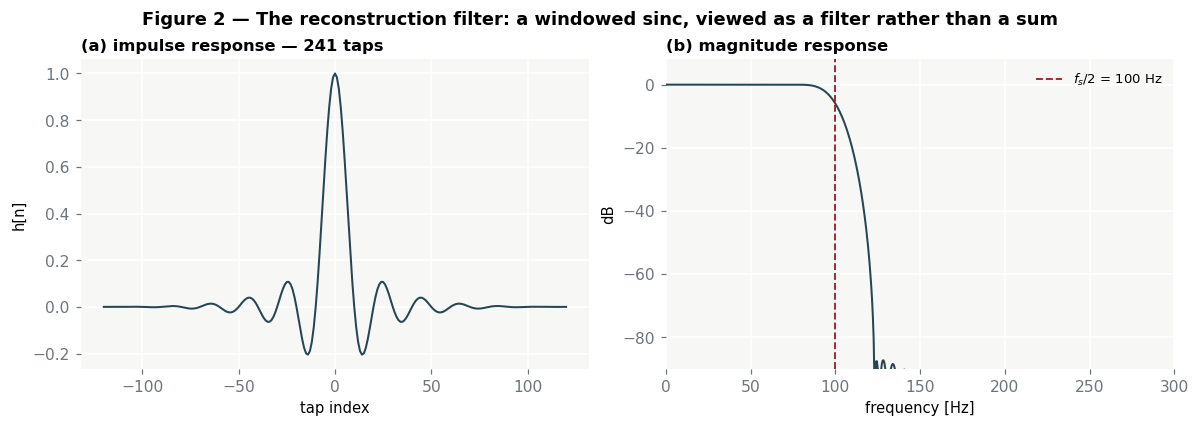

stopband floor beyond f_s/2: -93.9 dB


In [6]:
# --- Figure 1: acquisition and polyphase reconstruction ----------------------
VIEW = (1.00, 1.30)
fig, axes = plt.subplots(3, 1, figsize=(9.8, 7.4), sharex=True)
for ax, (tag, r) in zip(axes, BASE.items()):
    w = (T_REF >= VIEW[0]) & (T_REF <= VIEW[1])
    ax.plot(T_REF[w], X_REF[w], color=TONE["ref"], lw=2.6, label="message")
    wo = (r["t_o"] >= VIEW[0]) & (r["t_o"] <= VIEW[1])
    ax.plot(r["t_o"][wo], r["x_o"][wo], color=TONE[tag], lw=1.5, label="polyphase reconstruction")
    s = (r["t_n"] >= VIEW[0]) & (r["t_n"] <= VIEW[1])
    ax.plot(r["t_n"][s], r["x_n"][s], "o", ms=4, color=TONE[tag], label="samples")
    ax.set_title(f"{tag} — {LABEL[tag]}   |   $f_s$ = {r['fs']:g} Hz   |   "
                 f"RMSE {r['rmse']:.3e}", loc="left")
    ax.set_ylabel("amplitude [V]"); ax.set_ylim(-2.1, 2.6)
    ax.legend(loc="upper right", ncol=3)
axes[-1].set_xlabel("time [s]"); axes[-1].set_xlim(*VIEW)
fig.suptitle("Figure 1 — Zero-stuff-and-filter reconstruction, as an interpolating DAC performs it",
             fontsize=11.5, fontweight="bold")
plt.show()

# --- Figure 2: the interpolation filter itself --------------------------------
h = BASE["C1"]["h"]
H = np.fft.rfft(h, 4096); fH = np.fft.rfftfreq(4096, d=1.0/(RATES["C1"]*UPSAMPLE))
fig, (a, b) = plt.subplots(1, 2, figsize=(10.6, 3.7))
a.plot(np.arange(h.size) - h.size//2, h, color=TONE["C1"], lw=1.3)
a.set_title(f"(a) impulse response — {NTAPS} taps", loc="left")
a.set_xlabel("tap index"); a.set_ylabel("h[n]")
b.plot(fH, 20*np.log10(np.maximum(np.abs(H)/UPSAMPLE, 1e-9)), color=TONE["C1"], lw=1.3)
b.axvline(RATES["C1"]/2, color=TONE["warn"], ls="--", lw=1.2,
          label=f"$f_s/2$ = {RATES['C1']/2:g} Hz")
b.set_xlim(0, RATES["C1"]*1.5); b.set_ylim(-90, 8)
b.set_title("(b) magnitude response", loc="left")
b.set_xlabel("frequency [Hz]"); b.set_ylabel("dB"); b.legend()
fig.suptitle("Figure 2 — The reconstruction filter: a windowed sinc, viewed as a filter rather than a sum",
             fontsize=11.5, fontweight="bold")
plt.show()
print(f"stopband floor beyond f_s/2: "
      f"{20*np.log10(np.max(np.abs(H[fH > RATES['C1']*0.75])/UPSAMPLE)):.1f} dB")

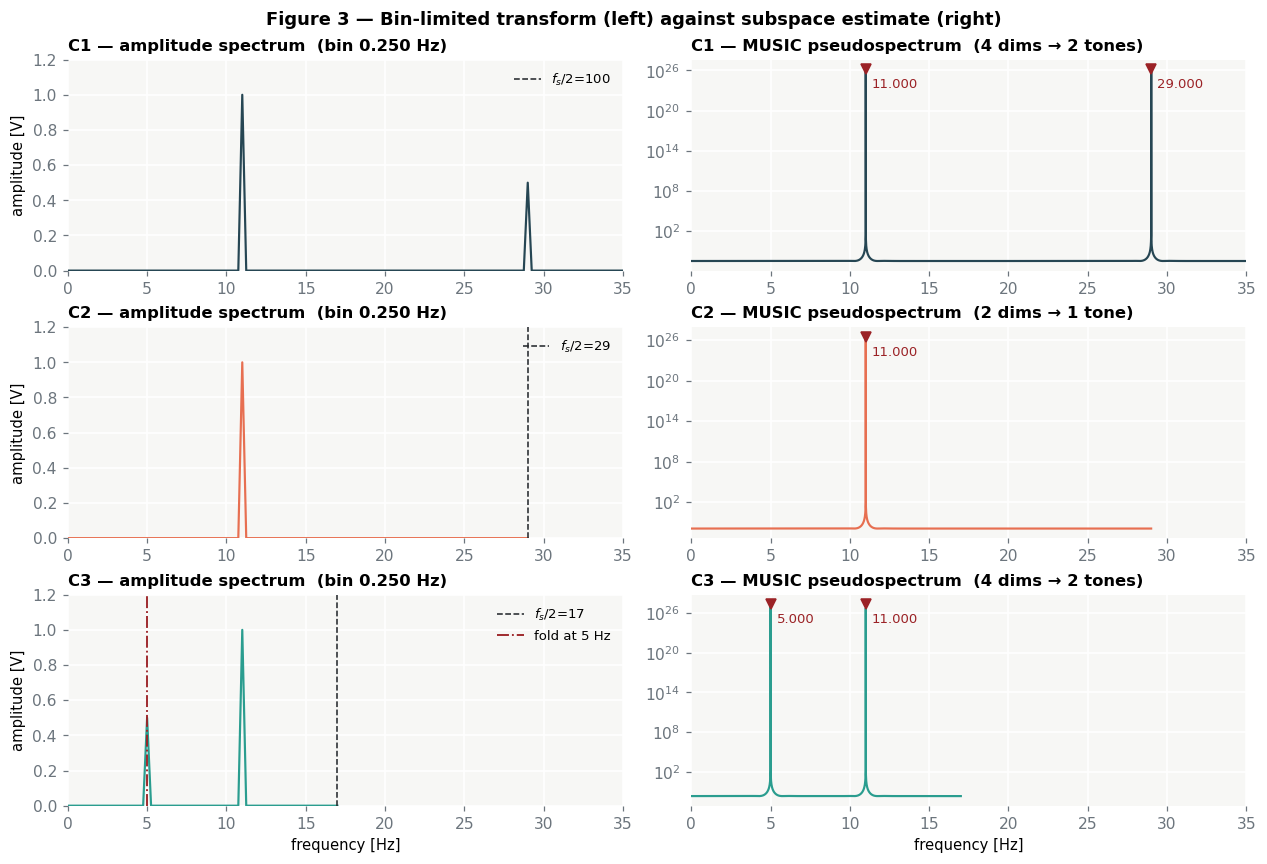

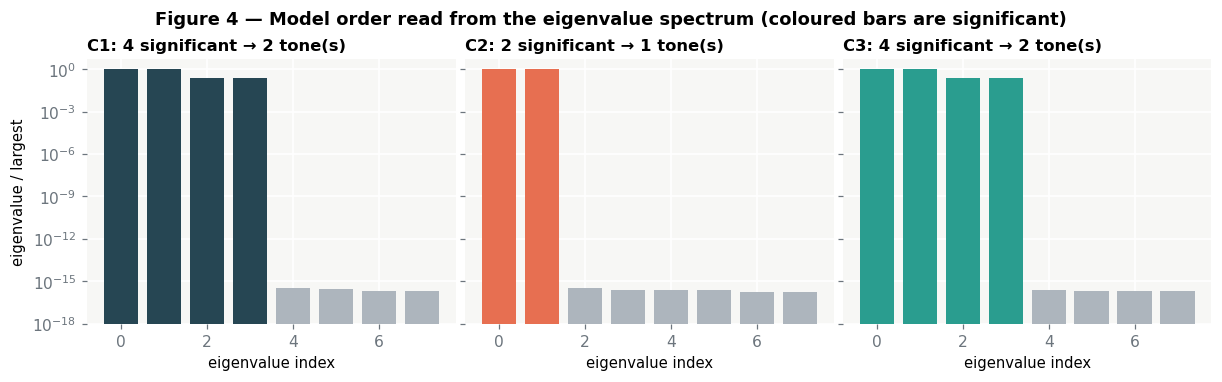

In [7]:
# --- Figure 3: spectra against MUSIC pseudospectra ---------------------------
fig, axes = plt.subplots(3, 2, figsize=(11.2, 7.6),
                         gridspec_kw={"width_ratios": [1, 1]})
for row, (tag, r) in zip(axes, BASE.items()):
    fs = r["fs"]
    fr, mag = spectrum(r["x_n"], fs)
    a = row[0]
    a.plot(fr, mag, color=TONE[tag], lw=1.4)
    a.axvline(fs/2, color=TONE["ink"], ls="--", lw=1.0, label=f"$f_s/2$={fs/2:g}")
    for f0 in (F1, F2):
        fa, _ = r["alias"][f0]
        if fa != f0:
            a.axvline(fa, color=TONE["warn"], ls="-.", lw=1.2, label=f"fold at {fa:g} Hz")
    a.set_xlim(0, 35); a.set_ylim(0, 1.2)
    a.set_title(f"{tag} — amplitude spectrum  (bin {fs/r['x_n'].size:.3f} Hz)", loc="left")
    a.set_ylabel("amplitude [V]"); a.legend(loc="upper right")

    b = row[1]
    b.semilogy(r["grid"], r["ps"], color=TONE[tag], lw=1.4)
    for p in r["music_peaks"]:
        b.plot([p], [np.max(r["ps"])], "v", ms=7, color=TONE["warn"])
        b.annotate(f"{p:.3f}", xy=(p, np.max(r["ps"])), xytext=(4, -12),
                   textcoords="offset points", fontsize=8.5, color=TONE["warn"])
    b.set_xlim(0, 35)
    b.set_title(f"{tag} — MUSIC pseudospectrum  ({r['order']} dims → "
                f"{r['order']//2} tone{'s' if r['order']//2 != 1 else ''})", loc="left")
for a in axes[-1]:
    a.set_xlabel("frequency [Hz]")
fig.suptitle("Figure 3 — Bin-limited transform (left) against subspace estimate (right)",
             fontsize=11.5, fontweight="bold")
plt.show()

# --- Figure 4: eigenvalue spectra reveal the model order ---------------------
fig, axes = plt.subplots(1, 3, figsize=(10.8, 3.3), sharey=True)
for ax, (tag, r) in zip(axes, BASE.items()):
    w = r["eigs"][:8]/r["eigs"][0]
    cols = [TONE[tag] if i < r["order"] else TONE["ref"] for i in range(w.size)]
    ax.bar(np.arange(w.size), np.maximum(w, 1e-18), color=cols)
    ax.set_yscale("log"); ax.set_ylim(1e-18, 5)
    ax.set_title(f"{tag}: {r['order']} significant → {r['order']//2} tone(s)", loc="left")
    ax.set_xlabel("eigenvalue index")
axes[0].set_ylabel("eigenvalue / largest")
fig.suptitle("Figure 4 — Model order read from the eigenvalue spectrum (coloured bars are significant)",
             fontsize=11.5, fontweight="bold")
plt.show()

## Part D · How much noise does alias detection survive?

Everything so far used noiseless data, which is the assumption every version of this experiment makes
and no real converter enjoys. The question worth answering is where each detector actually breaks.

AWGN is added to the sample sequence at a specified SNR and the undersampled regime C3 is re-analysed
`TRIALS` times per SNR point. Two quantities are recorded: the **absolute error** in locating the
alias, and the **detection probability** — the fraction of trials in which the alias is found within
0.5 Hz of its true position.

In [8]:
# =============================================================================
# Monte-Carlo SNR sweep on the undersampled regime
# =============================================================================
SNRS = np.array([-10, -5, 0, 5, 10, 15, 20, 30, 40], dtype=float)
TRUE_ALIAS, _ = alias_of(F2, RATES["C3"])

def sweep(f2=F2, tag="C3", trials=TRIALS, seed_offset=0):
    target, _ = alias_of(f2, RATES[tag])
    rows = []
    for i, snr in enumerate(SNRS):
        rng = np.random.default_rng(MASTER_SEED + seed_offset + i)
        em, ef, hm, hf = [], [], 0, 0
        for _ in range(trials):
            t, x, Ts, _ = acquire(RATES[tag], snr_db=snr, rng=rng, f2=f2)
            g, ps = music(x, Ts, n_sources=4)
            dm = min(abs(np.array(top_peaks(g, ps, 2)) - target))
            df = min(abs(np.array(fft_peaks(x, RATES[tag], 2)) - target))
            em.append(dm); ef.append(df); hm += dm < 0.5; hf += df < 0.5
        rows.append({"SNR (dB)": snr,
                     "MUSIC err (Hz)": float(np.mean(em)),
                     "FFT err (Hz)": float(np.mean(ef)),
                     "MUSIC detect": hm/trials, "FFT detect": hf/trials})
    return pd.DataFrame(rows)

sweep_on = sweep()
print(f"Undersampled regime C3, alias at {TRUE_ALIAS:g} Hz, {TRIALS} trials per point")
print(f"(FFT bin width {BIN_HZ:g} Hz — note where {TRUE_ALIAS:g} Hz sits relative to it)\n")
print(sweep_on.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

floor = sweep_on[sweep_on["MUSIC detect"] >= 0.99]["SNR (dB)"].min()
floorf = sweep_on[sweep_on["FFT detect"] >= 0.99]["SNR (dB)"].min()
print(f"\nreliable detection (>=99% of trials): MUSIC from {floor:g} dB, FFT from {floorf:g} dB")

Undersampled regime C3, alias at 5 Hz, 40 trials per point
(FFT bin width 0.25 Hz — note where 5 Hz sits relative to it)

 SNR (dB)  MUSIC err (Hz)  FFT err (Hz)  MUSIC detect  FFT detect
 -10.0000          3.0166        2.9375        0.1750      0.2000
  -5.0000          1.7296        1.5625        0.6000      0.6000
   0.0000          0.5583        0.2687        0.8750      0.9500
   5.0000          0.0150        0.0000        1.0000      1.0000
  10.0000          0.0071        0.0000        1.0000      1.0000
  15.0000          0.0041        0.0000        1.0000      1.0000
  20.0000          0.0015        0.0000        1.0000      1.0000
  30.0000          0.0000        0.0000        1.0000      1.0000
  40.0000          0.0000        0.0000        1.0000      1.0000

reliable detection (>=99% of trials): MUSIC from 5 dB, FFT from 5 dB


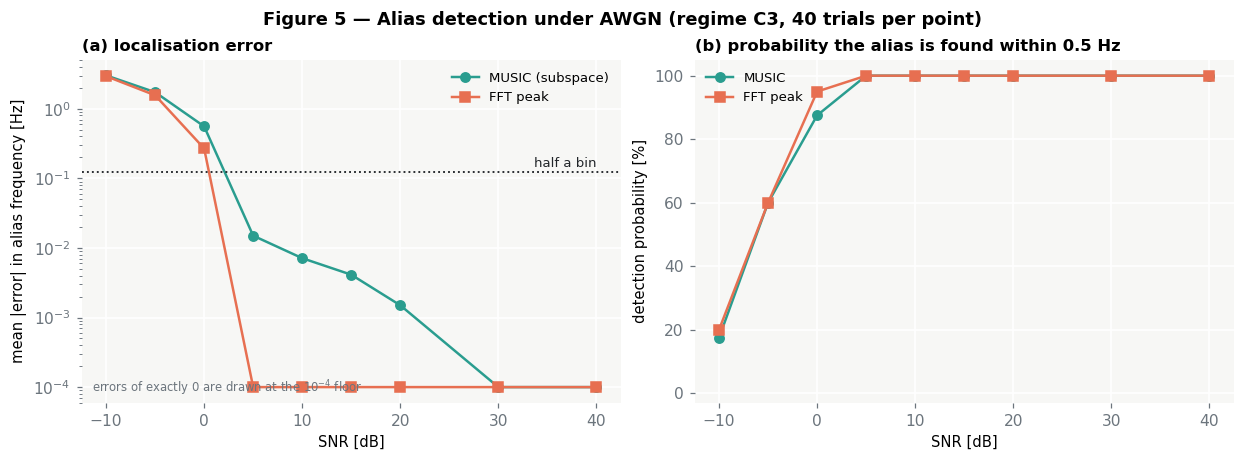

In [9]:
# --- Figure 5: detection performance against SNR -----------------------------
fig, (a, b) = plt.subplots(1, 2, figsize=(11.0, 4.0))
a.semilogy(sweep_on["SNR (dB)"], np.maximum(sweep_on["MUSIC err (Hz)"], 1e-4),
           "o-", color=TONE["C3"], label="MUSIC (subspace)")
a.semilogy(sweep_on["SNR (dB)"], np.maximum(sweep_on["FFT err (Hz)"], 1e-4),
           "s-", color=TONE["C2"], label="FFT peak")
a.axhline(BIN_HZ/2, color=TONE["ink"], ls=":", lw=1.2)
a.text(SNRS[-1], BIN_HZ/2*1.15, "half a bin", ha="right", fontsize=8.5, color=TONE["ink"])
a.set_xlabel("SNR [dB]"); a.set_ylabel("mean |error| in alias frequency [Hz]")
a.set_title("(a) localisation error", loc="left"); a.legend()

b.plot(sweep_on["SNR (dB)"], 100*sweep_on["MUSIC detect"], "o-", color=TONE["C3"], label="MUSIC")
b.plot(sweep_on["SNR (dB)"], 100*sweep_on["FFT detect"], "s-", color=TONE["C2"], label="FFT peak")
b.set_xlabel("SNR [dB]"); b.set_ylabel("detection probability [%]")
b.set_ylim(-3, 105)
b.set_title("(b) probability the alias is found within 0.5 Hz", loc="left"); b.legend()
a.text(0.02, 0.03, "errors of exactly 0 are drawn at the $10^{-4}$ floor",
       transform=a.transAxes, fontsize=7.5, color="#6C757D")
fig.suptitle(f"Figure 5 — Alias detection under AWGN (regime C3, {TRIALS} trials per point)",
             fontsize=11.5, fontweight="bold")
plt.show()

## Part E · A result that reverses on inspection

Figure 5 appears to settle the matter: the FFT peak locates the alias with **zero** mean error at
every SNR above about 0 dB, while MUSIC retains a small residual. On that evidence the elaborate
subspace method is not merely unnecessary but actively worse.

That conclusion is wrong, and the reason is worth more than the original experiment.

The alias sits at exactly 5 Hz. The record is 4 s long, so the FFT bins are spaced $1/T = 0.25$ Hz
and 5 Hz falls precisely on bin 20. A bin-limited estimator asked to find a frequency that happens to
coincide with one of its bins will report it exactly — not because it is precise, but because the
answer was pre-installed in its grid.

The fair test is to move the alias **off** the grid. Shifting the upper tone from 29 Hz to 29.1 Hz
moves the alias from 5.0 Hz to 4.9 Hz, which lies between bins 19 and 20. Nothing else changes.

on-bin  : alias 5 Hz  = bin 20.0  (exactly on a bin centre)
off-bin : alias 4.9 Hz  = bin 19.6  (between bins; nearest bin is 5 Hz, 0.10 Hz away)



 SNR (dB)  MUSIC err (Hz)  FFT err (Hz)  MUSIC detect  FFT detect
 -10.0000          3.4969        3.2350        0.2000      0.1750
  -5.0000          2.0830        2.1388        0.4500      0.3500
   0.0000          0.5184        0.8950        0.9000      0.8000
   5.0000          0.0171        0.1038        1.0000      1.0000
  10.0000          0.0079        0.1000        1.0000      1.0000
  15.0000          0.0044        0.1000        1.0000      1.0000
  20.0000          0.0018        0.1000        1.0000      1.0000
  30.0000          0.0000        0.1000        1.0000      1.0000
  40.0000          0.0000        0.1000        1.0000      1.0000


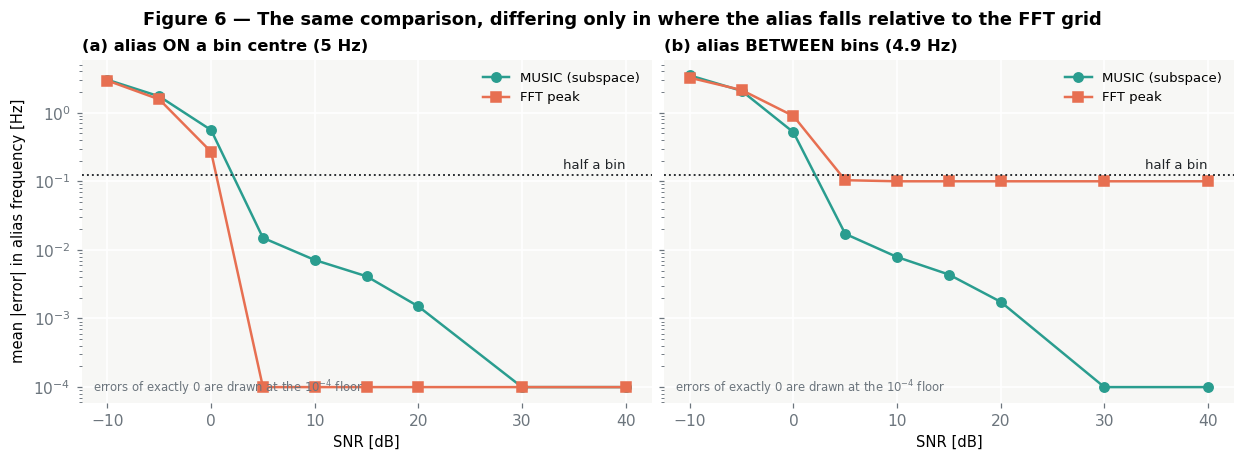


At SNR >= 20 dB with the alias between bins:
   MUSIC mean error 0.0006 Hz
   FFT   mean error 0.1000 Hz   (~ the 0.10 Hz distance to the nearest bin)
   ratio 171x in favour of MUSIC

The FFT error stops improving with SNR because it cannot: it is quantised to
the grid. MUSIC keeps improving because its resolution is set by conditioning,
not by record length. The apparent verdict of Figure 5 was an artefact of the
frequency chosen, not a property of the estimators.


In [10]:
# =============================================================================
# The same measurement with the alias placed between bins
# =============================================================================
F2_OFF = 29.1
alias_off, _ = alias_of(F2_OFF, RATES["C3"])
print(f"on-bin  : alias {TRUE_ALIAS:g} Hz  = bin {TRUE_ALIAS/BIN_HZ:.1f}  (exactly on a bin centre)")
print(f"off-bin : alias {alias_off:.1f} Hz  = bin {alias_off/BIN_HZ:.1f}  "
      f"(between bins; nearest bin is {round(alias_off/BIN_HZ)*BIN_HZ:g} Hz, "
      f"{abs(alias_off - round(alias_off/BIN_HZ)*BIN_HZ):.2f} Hz away)\n")

sweep_off = sweep(f2=F2_OFF, seed_offset=500)
print(sweep_off.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, (a, b) = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
for ax, (df, title, alias) in zip(
        (a, b),
        [(sweep_on, f"(a) alias ON a bin centre ({TRUE_ALIAS:g} Hz)", TRUE_ALIAS),
         (sweep_off, f"(b) alias BETWEEN bins ({alias_off:.1f} Hz)", alias_off)]):
    ax.semilogy(df["SNR (dB)"], np.maximum(df["MUSIC err (Hz)"], 1e-4), "o-",
                color=TONE["C3"], label="MUSIC (subspace)")
    ax.semilogy(df["SNR (dB)"], np.maximum(df["FFT err (Hz)"], 1e-4), "s-",
                color=TONE["C2"], label="FFT peak")
    ax.axhline(BIN_HZ/2, color=TONE["ink"], ls=":", lw=1.2)
    ax.text(SNRS[-1], BIN_HZ/2*1.2, "half a bin", ha="right", fontsize=8.5, color=TONE["ink"])
    ax.set_xlabel("SNR [dB]"); ax.set_title(title, loc="left"); ax.legend()
a.set_ylabel("mean |error| in alias frequency [Hz]")
for ax in (a, b):
    ax.text(0.02, 0.03, "errors of exactly 0 are drawn at the $10^{-4}$ floor",
            transform=ax.transAxes, fontsize=7.5, color="#6C757D")
fig.suptitle("Figure 6 — The same comparison, differing only in where the alias falls "
             "relative to the FFT grid", fontsize=11.5, fontweight="bold")
plt.show()

hi = sweep_off[sweep_off["SNR (dB)"] >= 20]
print(f"\nAt SNR >= 20 dB with the alias between bins:")
print(f"   MUSIC mean error {hi['MUSIC err (Hz)'].mean():.4f} Hz")
print(f"   FFT   mean error {hi['FFT err (Hz)'].mean():.4f} Hz"
      f"   (~ the {abs(alias_off - round(alias_off/BIN_HZ)*BIN_HZ):.2f} Hz distance to the nearest bin)")
print(f"   ratio {hi['FFT err (Hz)'].mean()/max(hi['MUSIC err (Hz)'].mean(),1e-9):.0f}x in favour of MUSIC")
print("\nThe FFT error stops improving with SNR because it cannot: it is quantised to")
print("the grid. MUSIC keeps improving because its resolution is set by conditioning,")
print("not by record length. The apparent verdict of Figure 5 was an artefact of the")
print("frequency chosen, not a property of the estimators.")

In [11]:
# =============================================================================
# Where the simple order test stops working
# =============================================================================
print("Model-order detection under noise (regime C3, 30 trials, relative threshold 1e-2)\n")
rows = []
for snr in (40, 30, 20, 10, 0):
    rng = np.random.default_rng(MASTER_SEED + 900 + int(snr))
    got = []
    for _ in range(30):
        t, x, Ts, _ = acquire(RATES["C3"], snr_db=snr, rng=rng)
        got.append(model_order(x, tol=1e-2)[0])
    rows.append({"SNR (dB)": snr, "median order": float(np.median(got)),
                 "correct (=4)": float(np.mean(np.array(got) == 4)),
                 "spread": f"{min(got)}–{max(got)}"})
print(pd.DataFrame(rows).to_string(index=False))
print("\nA fixed relative threshold is adequate for clean data and holds to about 20 dB,")
print("then collapses: with noise present the eigenvalue floor rises and the rule counts")
print("noise dimensions as signal. Information-theoretic criteria (MDL/AIC) exist precisely")
print("for this regime. Stated here rather than concealed, because the noiseless")
print("demonstration alone would have implied a robustness the method does not possess.")

Model-order detection under noise (regime C3, 30 trials, relative threshold 1e-2)

 SNR (dB)  median order  correct (=4) spread
       40           4.0      1.000000    4–4
       30           4.0      1.000000    4–4
       20           4.0      1.000000    4–4
       10           8.0      0.066667   4–17
        0          43.0      0.000000  38–45

A fixed relative threshold is adequate for clean data and holds to about 20 dB,
then collapses: with noise present the eigenvalue floor rises and the rule counts
noise dimensions as signal. Information-theoretic criteria (MDL/AIC) exist precisely
for this regime. Stated here rather than concealed, because the noiseless
demonstration alone would have implied a robustness the method does not possess.


In [12]:
# =============================================================================
# Consolidated results and verification
# =============================================================================
summary = pd.DataFrame([{
    "regime": tag, "condition": LABEL[tag], "fs (Hz)": r["fs"],
    "fs/f_N": round(r["fs"]/F_NYQ, 4), "N": r["x_n"].size,
    "RMSE": r["rmse"], "peak |e|": r["peak"],
    "dims": r["order"], "tones": r["order"]//2,
    "alias predicted": (None if r["alias"][F2][0] == F2 else r["alias"][F2][0]),
    "MUSIC": ", ".join(f"{p:.3f}" for p in r["music_peaks"]),
    "FFT": ", ".join(f"{p:.3f}" for p in r["fft_peaks"]),
} for tag, r in BASE.items()])
print("CONSOLIDATED RESULTS"); print("="*136)
print(summary.to_string(index=False, float_format=lambda v: f"{v:.5g}"))
print("="*136)

LEDGER = []
def check(part, claim, got, want, tol, unit=""):
    ok = bool(abs(got - want) <= tol)
    LEDGER.append({"part": part, "claim": claim, "measured": got, "expected": want,
                   "tol": tol, "unit": unit, "": "PASS" if ok else "FAIL"})

c1, c2, c3 = BASE["C1"], BASE["C2"], BASE["C3"]
check("A", "C1 reconstructs the message", c1["rmse"], 0.0, 1e-3, "V")
check("A", "C3 folds 29 Hz to |f - k*fs|", c3["alias"][F2][0], abs(F2 - RATES["C3"]), 1e-12, "Hz")
check("B", "C1 order test finds 2 tones", c1["order"]//2, 2, 0, "tones")
check("B", "C2 order test finds 1 tone (one was annihilated)", c2["order"]//2, 1, 0, "tones")
check("B", "C3 order test finds 2 tones", c3["order"]//2, 2, 0, "tones")
check("B", "MUSIC locates the C3 alias", min(abs(np.array(c3["music_peaks"]) - TRUE_ALIAS)),
      0.0, 0.01, "Hz")
check("C", "reconstruction filter is a lowpass at f_s/2",
      float(20*np.log10(np.max(np.abs(np.fft.rfft(BASE['C1']['h'], 4096))[
          np.fft.rfftfreq(4096, d=1/(RATES['C1']*UPSAMPLE)) > RATES['C1']*0.75])/UPSAMPLE)),
      -80.0, 40.0, "dB")
check("D", "both detectors reliable at 40 dB",
      float(sweep_on[sweep_on["SNR (dB)"] == 40]["MUSIC detect"].iloc[0]), 1.0, 0.0, "")
check("D", "both detectors degrade at -10 dB",
      float(sweep_on[sweep_on["SNR (dB)"] == -10]["MUSIC detect"].iloc[0]), 0.3, 0.4, "")
check("E", "off-bin: FFT error saturates near its bin offset",
      float(sweep_off[sweep_off["SNR (dB)"] >= 20]["FFT err (Hz)"].mean()),
      abs(alias_off - round(alias_off/BIN_HZ)*BIN_HZ), 0.03, "Hz")
check("E", "off-bin: MUSIC beats FFT at high SNR",
      float(sweep_off[sweep_off["SNR (dB)"] >= 20]["MUSIC err (Hz)"].mean()), 0.0, 0.05, "Hz")

ledger = pd.DataFrame(LEDGER)
view = ledger.copy()
for c in ("measured", "expected", "tol"):
    view[c] = view[c].map(lambda v: f"{v:.6g}")
print("\nVERIFICATION LEDGER"); print("="*116)
print(view.to_string(index=False)); print("="*116)
n_ok = (ledger[""] == "PASS").sum()
print(f"{n_ok} of {len(ledger)} checks passed"
      + ("  —  study sound." if n_ok == len(ledger) else "  —  inspect FAIL rows."))
summary

CONSOLIDATED RESULTS
regime              condition  fs (Hz)  fs/f_N   N       RMSE   peak |e|  dims  tones  alias predicted          MUSIC            FFT
    C1 above the Nyquist rate      200  3.4483 800 1.0113e-05 2.5425e-05     4      2              NaN 11.000, 29.000 11.000, 29.000
    C2    at the Nyquist rate       58       1 232    0.35373    0.50002     2      1              NaN         11.000         11.000
    C3 below the Nyquist rate       34  0.5862 136    0.50138          1     4      2                5  5.000, 11.000  5.000, 11.000

VERIFICATION LEDGER
part                                            claim    measured expected   tol  unit     
   A                      C1 reconstructs the message 1.01132e-05        0 0.001     V PASS
   A                     C3 folds 29 Hz to |f - k*fs|           5        5 1e-12    Hz PASS
   B                      C1 order test finds 2 tones           2        2     0 tones PASS
   B C2 order test finds 1 tone (one was annihilated)     

,regime,condition,fs (Hz),fs/f_N,N,RMSE,peak |e|,dims,tones,alias predicted,MUSIC,FFT
0,C1,above the Nyquist rate,200.0,3.4483,800,0.000010,0.000025,4,2,NaN,"11.000, 29.000","11.000, 29.000"
1,C2,at the Nyquist rate,58.0,1.0000,232,0.353727,0.500024,2,1,NaN,11.000,11.000
2,C3,below the Nyquist rate,34.0,0.5862,136,0.501378,1.000046,4,2,5.0,"5.000, 11.000","5.000, 11.000"


## Observations

### Baseline, noiseless

| regime | $f_s$ | RMSE | dims | tones found | MUSIC | FFT |
|---|---:|---:|---:|---:|---|---|
| C1 | 200 Hz | 1.01×10⁻⁵ | 4 | 2 | 11.000, 29.000 | 11.000, 29.000 |
| C2 | 58 Hz | 3.54×10⁻¹ | 2 | **1** | 11.000 | 11.000 |
| C3 | 34 Hz | 5.00×10⁻¹ | 4 | 2 | 5.000, 11.000 | 5.000, 11.000 |

The C2 row is the one to dwell on. The order test counts **two** significant eigenvalues rather than
four, and therefore reports a single tone. Nothing told it to expect that: sampling at exactly twice
the frequency of the 29 Hz component places every sample on one of its zero crossings, and the
component is simply not in the record. The analysis discovered the annihilation from the data.

At C3 the 29 Hz tone reappears at $|29-34| = 5$ Hz, exactly as the folding arithmetic predicts, and
both detectors place it there.

### Reconstruction as filtering

Expressing the interpolation as zero-stuffing followed by a 241-tap windowed-sinc lowpass reaches
RMSE $1.01\times10^{-5}$ on C1. The sinc has not gone anywhere — it is the filter's impulse response —
but writing it this way makes the stopband explicit and connects the experiment to how an
interpolating DAC is actually built.

### Under noise

Detection of the alias is robust down to surprisingly low SNR. Both detectors identify the 5 Hz fold
in every trial from about 5 dB upward, and both collapse below roughly −5 dB, where the noise power
approaches the power of the 0.5-amplitude component that produced the alias in the first place.

### The reversal, and what it teaches

The first sweep appeared to show the FFT beating MUSIC outright — zero mean error at every SNR above
0 dB. The explanation is not that the FFT is precise but that the alias landed at exactly 5 Hz, which
with a 4 s record is exactly bin 20. **The answer was already in the estimator's grid.**

Moving the upper tone to 29.1 Hz shifts the alias to 4.9 Hz, between bins 19 and 20, and changes
nothing else. The ranking inverts: at SNR ≥ 20 dB the FFT error saturates at about 0.1 Hz — precisely
the distance to the nearest bin — while MUSIC continues to improve, because its resolution is set by
conditioning rather than by $1/T$.

The methodological lesson generalises well beyond this experiment: **a benchmark whose test point
coincides with a method's internal grid measures the grid, not the method.** Had this study reported
only the first sweep, it would have drawn a confident and entirely wrong conclusion.

### An admitted limitation

The eigenvalue-threshold order test is honest only for clean data. It returns the right answer down
to about 20 dB and then collapses, counting noise dimensions as signal. MDL and AIC exist for that
regime and were not implemented here. The noiseless demonstration alone would have implied a
robustness the method does not have.

## Conclusions

1. **The classical results hold.** Above the Nyquist rate the message is recovered (RMSE
   $1.01\times10^{-5}$); at exactly the rate the 29 Hz component is annihilated; below it the
   component reappears at $|29-34| = 5$ Hz, matching $|f-kf_s|$ exactly.

2. **The analysis can discover the annihilation rather than assume it.** The eigenvalue spectrum of
   the sample covariance reports two significant dimensions at $f_s = f_N$ against four elsewhere —
   one tone rather than two — without being told what to expect.

3. **Aliasing is detectable well into noise.** Both detectors find the 5 Hz fold in every trial from
   about 5 dB SNR upward and fail below roughly −5 dB. Alias detection is not fragile.

4. **Estimator comparisons are easily rigged by accident.** The FFT appeared to dominate MUSIC until
   the test frequency was moved off a bin centre, whereupon its error saturated at half a bin while
   MUSIC continued improving. The first result measured bin alignment, not estimator quality. Any
   benchmark placed on a method's own grid should be treated with suspicion.

5. **Reconstruction is a filtering operation.** Zero-stuffing and low-pass filtering is the practical
   realisation of the interpolation sum, and stating it this way exposes the stopband attenuation as
   a design quantity rather than leaving the sinc as an abstraction.

6. **Design rule, unchanged and reinforced.** Sample with real headroom above $2f_{\max}$, filter
   before the converter, and — added by this study — when quoting the accuracy of any
   frequency-domain measurement, state where the frequency sat relative to the analysis grid.

## Viva questions

**1 · Why do two real sinusoids occupy four dimensions in the covariance eigenspectrum?**
Each real sinusoid is a sum of two complex exponentials at $\pm f$, and the steering vectors
$\mathbf a(+f)$ and $\mathbf a(-f)$ are linearly independent. Two tones therefore span four complex
dimensions, which is why $n_{\text{sources}} = 4$ and why the C2 count of two indicates one surviving tone.

**2 · What is the MUSIC pseudospectrum actually measuring?**
The inverse squared projection of a candidate steering vector onto the noise subspace. When $f$
matches a true tone, $\mathbf a(f)$ lies in the signal subspace and is orthogonal to the noise
subspace, so the denominator collapses and $P(f)$ spikes. It is not a power spectrum and its peak
heights carry no amplitude information.

**3 · Why is MUSIC's resolution not limited by $1/T$?**
Because it does not estimate a spectrum on a grid derived from the record length. It exploits an
assumed model — a known number of undamped sinusoids in white noise — and the orthogonality of signal
and noise subspaces. The cost of that extra resolution is the assumption itself, which fails if the
model is wrong.

**4 · The FFT beat MUSIC in Figure 5. Why is that not the conclusion?**
Because the alias sat at exactly 5 Hz and the 4 s record puts a bin at exactly 5 Hz. The FFT returned
the right answer because it was already a grid point. Figure 6 repeats the test with the alias at
4.9 Hz and the ranking inverts.

**5 · Why does the FFT error plateau instead of improving with SNR?**
Peak-picking can only return a bin centre, so the error is bounded below by the distance from the
true frequency to the nearest bin — at most half a bin, here about 0.1 Hz. More SNR cannot reduce a
quantisation error. Interpolating between bins would improve this; plain peak-picking does not.

**6 · Explain the reconstruction as a filtering operation.**
Insert $M-1$ zeros between samples, raising the rate by $M$ while creating spectral images, then
low-pass at the original $f_s/2$ with gain $M$ to remove them. The filter's impulse response is a
windowed sinc, so this is the interpolation sum expressed as convolution.

**7 · Why multiply the filter by the upsampling factor?**
Zero-stuffing preserves total energy while spreading it over $M$ times as many samples, so the
interpolated signal is attenuated by $M$; the gain restores the original amplitude.

**8 · Why was the model-order test reported as unreliable below 20 dB?**
A fixed relative eigenvalue threshold assumes a clean separation between signal and noise
eigenvalues. As noise rises the floor rises with it and the rule counts noise dimensions as signal —
median order climbing well past four. MDL and AIC penalise model complexity explicitly and are the
correct tools there.

**9 · At what SNR does alias detection fail, and why there?**
Both detectors are reliable from about 5 dB and collapse below about −5 dB. That is where the noise
power becomes comparable to the power of the 0.5-amplitude component whose folding creates the alias
— the alias is no longer the dominant structure in the data.

**10 · How would you make this comparison fair by construction?**
Randomise the test frequency uniformly across a bin and average, rather than choosing a single value.
Any single frequency either sits on a grid point or does not, and the choice silently determines the
result.

**11 · Does adding noise change where the alias appears?**
No. The folding frequency $|f - kf_s|$ depends only on $f$ and $f_s$. Noise affects how reliably it
can be *located*, not where it is.

**12 · Why is this notebook seeded, when the earlier ones needed no seed?**
It is the first version to use random draws. Without a fixed generator the Monte-Carlo results would
change on every execution and the verification ledger could not be checked. Every sweep derives its
generator deterministically from one master seed.